# Tutorial 4: Generative Brain-to-Text (LLM)

This tutorial shows how to generate natural language descriptions of brain activation patterns using a local language model.

**Pipeline (brain → text)**
```
Brain → Autoencoder Encoder → Projection Head → Contrastive Retrieval → LLM → Text
```

**Pipeline (text → brain, with LLM context)**
```
Text Query → to_brain() → [internal text-to-text retrieval] → LLM → Text
```

You will learn:
1. Setting up an LLM backend (Ollama or HuggingFace)
2. Generating text from a brain activation map (brain-to-text mode)
3. Generating text from a text query with neuroscience context (text-to-brain mode)
4. Customising prompts and filtering the context table
5. Labelling multiple networks in a loop

## 0. LLM Backend Setup

`generate_llm_response` supports two backends — pick whichever fits your environment.

### Option A — Ollama (recommended, fast)

```bash
# Install (macOS)
brew install ollama

# Or Linux
sudo apt install zstd
curl -fsSL https://ollama.com/install.sh | sh

# Install to env
pip install neurovlm[llm]
```

Then

```bash
# Start the server
ollama serve

# Pull a model
ollama pull llama3.2:3b          # lightweight, good quality
ollama pull qwen2.5:3b           # alternative
```

### Option B — HuggingFace (no server required, works offline)

```bash
pip install transformers accelerate
```

Model suggestions:
- `"HuggingFaceTB/SmolLM2-360M-Instruct"` — very fast, ~700 MB
- `"Qwen/Qwen2.5-1.5B-Instruct"` — better quality, ~3 GB
- `"Qwen/Qwen2.5-3B-Instruct"` — best quality, ~6 GB

> **Note:** `model_name` is always required — there is no default. Omitting it raises an error.

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from neurovlm import NeuroVLM
from neurovlm.data import load_latent

nvlm = NeuroVLM(device="cpu")

## 1. Brain-to-Text Generation

When you run `brain(...).to_text()`, the contrastive model retrieves the most similar
publications, NeuroWiki concepts, and CogAtlas terms for the input brain image.

You then inspect the table — filtering it however you like — and pass it directly to
`generate_llm_response` via the `table=` argument. The LLM uses exactly those rows
as context, and is aware the terms were found through neuroimage similarity.

### Load a brain network

In [2]:
# Load pre-encoded network atlases
networks = load_latent("networks_neuro")

# We'll use the auditory network from Du et al.
auditory_network = networks["Du"]["AUD"]

### Step 1 — Contrastive retrieval

Run `brain(...).to_text()` to rank the most similar text across all datasets.
A threshold of 0.4 is a reliable cutoff for meaningful brain-to-text associations.

In [3]:
result = nvlm.brain(auditory_network).to_text()

# Filter to the rows you actually want the LLM to see
context_table = result.top_k(5).query("cosine_similarity > 0.4")
context_table

,dataset,title,description,cosine_similarity
0,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245
3,cogatlas,acoustic phonetic processing,The cognitive ability to discriminate items on...,0.423635
4,cogatlas,auditory tone detection,Determining the presence of an auditory stimul...,0.417665
5,networks,Auditory,Auditory network (AUD; auditory cortex network...,0.470543
10,pubmed,The processing of temporal pitch and melody in...,An fMRI experiment was performed to identify t...,0.526884
11,pubmed,"Heschl's gyrus, posterior superior temporal gy...",A part of the auditory system automatically de...,0.504547
12,pubmed,Hierarchical processing of sound location and ...,Horizontal sound localization relies on the ex...,0.499913
13,pubmed,Brain bases for auditory stimulus-driven figur...,"Auditory figure-ground segregation, listeners'...",0.490401


### Step 2 — Generate with Ollama

Pass `table=context_table` so the LLM sees exactly the rows you inspected above.

In [4]:
response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="qwen2.5:3b",   # must be pulled first: ollama pull qwen2.5:3b
    table=context_table,       # use the filtered table — k is ignored when table is set
)
print(response)

### Overview of Cognitive Functions Implicated

The input brain activation pattern described by these studies primarily relates to auditory processing and perception, including pitch analysis, melody recognition, temporal processing, and spatial localization. This region encompasses primary auditory cortex (primarily Heschl's gyrus and planum temporale) as well as more posterior regions like the superior temporal gyrus (STG), planum polare (PP), inferior colliculus in the midbrain, and prefrontal cortex. These areas are crucial for various aspects of sound processing that support auditory scene analysis.

The neuroimaging experiments conducted show how different brain structures contribute to specific functions such as pitch perception, melody recognition, temporal resolution of acoustic changes, and stimulus-driven figure-ground segregation. Melodic expectation studies indicate the brain's predictive mechanisms involved in music cognition, with areas like planum temporale showing incr

### Step 2 (alt) — Generate with HuggingFace

Same `table=` argument works with the HuggingFace backend.

In [5]:
response = nvlm.generate_llm_response(
    backend="huggingface",
    model_name="Qwen/Qwen3-0.6B",
    table=context_table,
    max_new_tokens=512,
    verbose=False,
    think=False # Qwen3-0.6B has a "thinking" mode
)
print(response)


Loading HuggingFace model: Qwen/Qwen3-0.6B
Note: First-time download may take several minutes...
Progress indicators will appear below:

Step 1/2: Loading tokenizer...
✓ Tokenizer loaded

Step 2/2: Loading model (this may take a while)...
✓ Model loaded successfully!
  Device: cuda:0
  Model size: Qwen3-0.6B

The brain activation pattern, as indicated by the provided publications, suggests a hierarchical and dynamic processing of auditory information, particularly in the auditory cortex. This includes the detection of pitch and melody, as well as the processing of spatial and temporal cues, which are reflected in the use of Heschl's gyrus (HG), planum temporale (PT), and superior temporal gyrus (STG) for auditory scene analysis. The integration of binaural cues and the recognition of auditory features like pitch and melody are supported by the activation of these regions. Additionally, the results highlight the role of the intraparietal sulcus (IPS) and superior temporal sulcus (STS) 

### Querying a single dataset

You can also build the context table from a single dataset — e.g. only CogAtlas concepts.

In [ ]:
# Use only CogAtlas concepts as LLM context
cogatlas_table = result.top_k(5, dataset="cogatlas").query("cosine_similarity > 0.4")
print(cogatlas_table[["title", "cosine_similarity"]])

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=cogatlas_table,
)
print(response)

                          title  cosine_similarity
0   auditory stream segregation           0.437669
1             auditory encoding           0.431347
2               music cognition           0.431245
3  acoustic phonetic processing           0.423635
4       auditory tone detection           0.417665
Based on the provided cognitive terms from the Cognitive Atlas, the brain activation pattern appears to be associated with multiple aspects of auditory processing and perception.

At its core, this brain activation pattern suggests heightened activity in areas related to auditory stream segregation, indicating an individual's ability to group sounds together into coherent representations of objects in their acoustic environment. This process is fundamental to hearing and speech perception (NeuroWiki), highlighting the brain's capacity to organize and make sense of complex auditory information.

Furthermore, this pattern may also be linked to auditory encoding, as it reveals increased a

In [25]:
nvlm = NeuroVLM()
result = nvlm.brain(auditory_network).to_text()
# Use only CogAtlas concepts as LLM context
cogatlas_table = result.top_k(5, dataset="cogatlas").query("cosine_similarity > 0.4")
print(cogatlas_table[["title", "cosine_similarity"]])

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=cogatlas_table,
)
print(response)

                          title  cosine_similarity
0   auditory stream segregation           0.437669
1             auditory encoding           0.431347
2               music cognition           0.431245
3  acoustic phonetic processing           0.423635
4       auditory tone detection           0.417665
**Overview**

The brain activation pattern appears to be associated with multiple aspects of auditory perception and cognition. The involvement of auditory stream segregation, auditory encoding, music cognition, acoustic phonetic processing, and auditory tone detection suggests that the brain is actively processing complex auditory information.

**Neuroscientific Mechanisms**

According to NeuroWiki, the concept of auditory stream segregation (also known as auditory grouping) refers to the process by which our brains group together sounds that are perceived as coming from the same source, allowing us to identify objects and locations in the acoustic scene. This process is thought to be

## 2. Text-to-Brain Generation

When you run `text(...).to_brain()`, NeuroVLM generates (or retrieves) brain maps
for your query.

Calling `generate_llm_response` afterwards automatically runs a text-to-text
similarity search **internally** — you do not need to call `to_text()` yourself.
The LLM uses the resulting publications and concepts as context to:
- Define the user's query term
- Explain how the top neuroscience concepts relate to it

The brain result stored on the instance is **not overwritten**.

### Generate a brain map, then describe the concept

There are adapters available but none are activated for the forward pass.


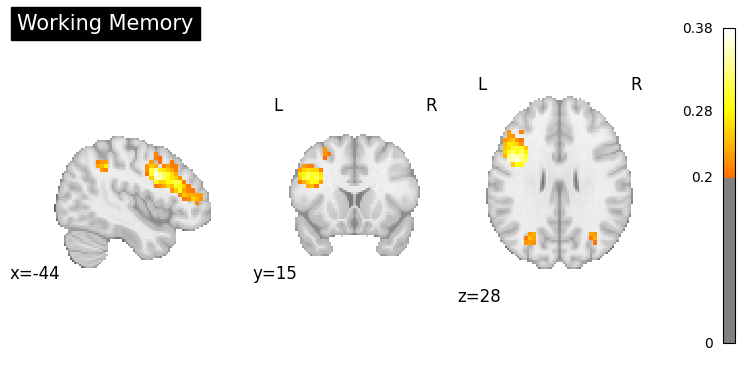

In [7]:
# Generate brain map from text
brain_result = nvlm.text("working memory").to_brain(head="mse")
brain_result.plot(threshold=0.2, title="Working Memory");

In [8]:
# Internal text-to-text retrieval happens automatically; k controls how many rows it fetches
response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="qwen2.5:3b",
    k=5,
)
print(response)

### Overview:
The publications provide insights into how neurocognitive processes, particularly those related to deductive reasoning, arithmetic, and attentional control mechanisms, vary with parental education levels. Additionally, they highlight the compensatory recruitment of neuronal resources during working memory processing in older adults and frontal lobe abnormalities in first-episode schizophrenia patients. These findings are contextualized using Cognitive Atlas terms such as working memory maintenance, visuospatial sketch pad, learning, and updating to provide additional perspective on cognitive functions.

### Key Findings:

#### Parental Education and Deductive Reasoning:
The studies underscore the critical role of parental education levels in shaping a child's neurocognitive basis for higher-order reasoning tasks. Higher parental education was associated with increased reliance on the left inferior frontal gyrus, which is implicated in verbal systems, when children solved 

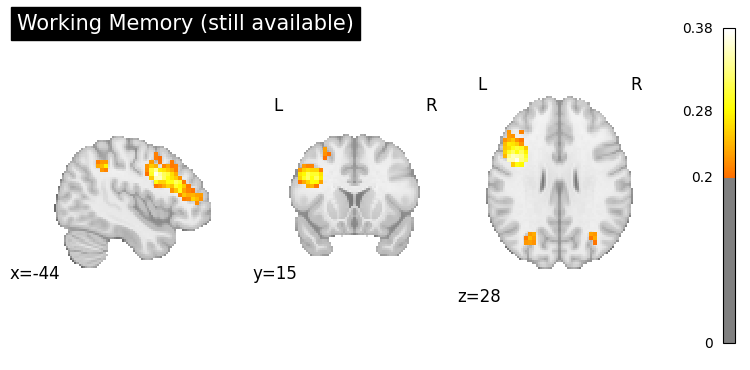

In [9]:
# The brain result is still available — it was not overwritten
brain_result.plot(threshold=0.2, title="Working Memory (still available)");

## 3. Adding a Custom User Prompt

Pass `user_prompt` to steer the LLM's focus — e.g. ask a specific question or
request a particular output format.

In [14]:
result = nvlm.brain(networks["YeoLab"]["DefaultA"]).to_text()
context_table = result.top_k(5).query("cosine_similarity > 0.4")

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=context_table,
    user_prompt="What clinical conditions are associated with this network?",
)
print(response)

**Overview**

The provided brain activation pattern suggests involvement of the default mode network (DMN), particularly the medial prefrontal cortex (mPFC) and posterior cingulate/precuneus, which are primary regions associated with self-referential thought, autobiographical/episodic memory, future simulation, social inference, and narrative/semantic integration. The activation pattern may also indicate altered connectivity patterns in the DMN compared to healthy controls.

**Convergent themes**

The NeuroWiki concepts highlight the importance of the DMN in internally oriented cognition, self-referential thought, and autobiographical/episodic memory. The Cognitive Atlas terms suggest that alterations in DMN connectivity have been observed in individuals with Alzheimer's disease (AD) and autism spectrum disorder (ASD). Additionally, reduced functional coupling in the DMN during self-referential processing has been reported.

**Network associations**

The brain activation pattern may be

In [16]:
# Request a concise bullet-point summary
result = nvlm.brain(networks["YeoLab"]["SomMotA"]).to_text()
context_table = result.top_k(5).query("cosine_similarity > 0.4")

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=context_table,
    user_prompt="Summarise in three bullet points, suitable for a non-expert audience.",
)
print(response)

**Summary in three bullet points**

The brain activation pattern discussed in these publications suggests that it is associated with motor functions and processes. Here are three key aspects:

• **Motor network activity**: The brain activation patterns suggest that the motor networks, including primary motor cortex (M1), supplementary motor area (SMA), premotor cortex, and sensorimotor integration regions, are active during motor tasks or rest. This is consistent with the concept of motor control, where these areas work together to plan and execute voluntary movements.

• **Proprioceptive feedback and context-sensitive output**: The data also suggest that proprioceptive feedback plays a crucial role in motor control. For example, the supplementary motor area (SMA) shows increased activity when proprioception is altered, indicating that it may be involved in context-sensitive output for motor control. This is supported by the concept of motor control, where proprioceptive information he

## 4. Labelling Multiple Networks

Loop over networks: run contrastive retrieval, inspect the filtered table,
then pass it to `generate_llm_response`.

In [20]:
target_networks = {
    "Visual":       networks["YeoLab"]["VisualA"],
    "Auditory":     networks["Du"]["AUD"],
    "Motor":        networks["YeoLab"]["SomMotA"],
    "Default Mode": networks["YeoLab"]["DefaultA"],
    "Language":     networks["Du"]["LANG"],
}

for name, latent in target_networks.items():
    print(f"\n{'='*60}")
    print(f"Network: {name}")
    print('='*60)

    result = nvlm.brain(latent).to_text()

    # Build and inspect the filtered context table
    context_table = result.top_k(5).query("cosine_similarity > 0.4")
    if not context_table.empty:
        print(context_table[["dataset", "title", "cosine_similarity"]].to_string(index=False))
    else:
        print("(no matches above threshold)")
        continue  # skip generation if nothing passed the threshold

    # Generate using exactly the rows above
    response = nvlm.generate_llm_response(
        backend="ollama",
        model_name="llama3.2:3b",
        table=context_table,
        verbose=False,
    )
    print(f"\n{response}")


Network: Visual
 dataset                                                                                                       title  cosine_similarity
cogatlas                                                                                           object perception           0.452152
cogatlas                                                                                          animacy perception           0.447128
cogatlas                                                                                               visual search           0.432990
cogatlas                                                                                   figure ground segregation           0.413456
cogatlas                                                                                           feature detection           0.403889
networks                                                                                                      Visual           0.470024
  pubmed                     Lo

## 5. Querying a Specific Dataset Before Generating

Pass `datasets` to `to_text()` to retrieve only from one source, then build
the context table from that restricted result.

In [21]:
# Retrieve only PubMed papers for the visual network
visual = networks["YeoLab"]["VisualA"]
result = nvlm.brain(visual).to_text(datasets=["pubmed"])

context_table = result.top_k(3, dataset="pubmed")
print("Papers used as context:")
print(context_table[["title", "cosine_similarity"]].to_string(index=False))

Papers used as context:
                                                                                      title  cosine_similarity
    Location and spatial profile of category-specific regions in human extrastriate cortex.           0.516058
Haptic perception and body representation in lateral and medial occipito-temporal cortices.           0.512238
   fMRI-adaptation studies of viewpoint tuning in the extrastriate and fusiform body areas.           0.511523


In [24]:
# LLM will only have paper context (no wiki or cogatlas)
response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=context_table,
)
print(response)

The brain activation patterns presented in these publications suggest a complex interplay between various cognitive functions, including category-specific perception, body representation, and viewpoint tuning. Here is a brief overview of the main cognitive functions implicated:

The extrastriate cortex, particularly the fusiform face area (FFA), extrastriate body area (EBA), parahippocampal place area (PPA), lateral occipital complex (LOC), and MT+/V5, are regions that show category-specific responses to different visual stimuli. The FFA and EBA, in particular, are involved in the perception of faces and body parts, respectively.

The haptic exploration of body parts also activates these regions, suggesting a multimodal representation of the body that integrates visual and somatosensory information. Furthermore, the activation patterns reveal different body representations in the occipito-temporal cortex, which are activated during perception and imagery of human body parts.

The viewp

## 6. Summary

In this tutorial you learned:

1. **LLM backends**: Ollama (fast, requires local server) and HuggingFace (offline, no server).
   `model_name` is always required — there is no default.

2. **Brain-to-text mode** (`brain(...).to_text()` → `generate_llm_response`):
   - Contrastive retrieval ranks the most similar publications, NeuroWiki concepts,
     and CogAtlas terms for the input brain map.
   - You inspect and filter the table yourself (e.g. `top_k(5).query("cosine_similarity > 0.4")`).
   - Pass `table=` to `generate_llm_response` — the LLM sees exactly those rows.
   - The LLM frames the terms in the context of neuroimage similarity.

3. **Text-to-brain mode** (`text(...).to_brain()` → `generate_llm_response`):
   - An internal text-to-text retrieval is run automatically — no extra call needed.
   - Use `k=` to control how many rows are fetched internally.
   - The LLM defines the user's query term and explains how the top neuroscience
     concepts relate to it. The stored brain result is preserved.

4. **`user_prompt`**: steer the LLM towards a specific question or output format.

5. **Batch labelling**: loop over networks — build the filtered `context_table` per network
   and pass it to `generate_llm_response`.

6. **Dataset filtering**: pass `datasets=["pubmed"]` (or any subset) to `to_text()`
   to restrict what context the LLM receives.

**Key tip**: larger models (≥ 7B parameters) produce noticeably better responses.
For production use, prefer `qwen2.5:7b-instruct` or `llama3.1:8b` via Ollama.